
# Decoding real-time EMG data

Following MNE tutorial with record made at nextAI


In [20]:
import numpy as np
import pandas as pd
import mne
from mne.decoding import Vectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ShuffleSplit, cross_val_score
import matplotlib.pyplot as plt
import time

In [24]:
# Load data
data = pd.read_csv('emg_recording_phantasiAI.csv')
emg_data = data['emg'].values.reshape(1, -1)  # (n_channels, n_samples)
timestamps = data['timestamp'].values
events = data['event'].values
event_times = timestamps[events]

print(f"EMG data shape: {emg_data.shape}")
print(f"Event data shape: {events.shape}")
print(f"Event times: {event_times}")

# Calculate sampling rate
sampling_rate = 1 / np.mean(np.diff(timestamps))
print(f"Sampling rate: {sampling_rate} Hz")

EMG data shape: (1, 7110)
Event data shape: (7110,)
Event times: [2.913636 2.913636 2.913636 ... 2.913636 2.913636 2.913636]
Sampling rate: 219.99999566746388 Hz


In [25]:
# Create MNE info and raw objects
info = mne.create_info(ch_names=['EMG'], sfreq=sampling_rate, ch_types=['emg'])
raw = mne.io.RawArray(emg_data, info)

Creating RawArray with float64 data, n_channels=1, n_times=7110
    Range : 0 ... 7109 =      0.000 ...    32.314 secs
Ready.


In [26]:
# Find events (where event column = 1)
event_samples = np.where(events == 1)[0]
mne_events = np.column_stack([event_samples, np.zeros_like(event_samples), np.ones_like(event_samples)])

print(f"# of events: {len(mne_events)}")

# Create epochs around events
epochs = mne.Epochs(raw, mne_events, tmin=-0.5, tmax=1, baseline=None, preload=True)

# Convert to numpy array
epochs = np.array(epochs)

print(f"Number of epochs: {len(epochs)}")
print(f"Samples per epoch: {len(epochs[0])}")
print(f"Epoch duration: {len(epochs[0])/sampling_rate:.3f} seconds")

# of events: 9
Not setting metadata
9 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 9 events and 331 original time points ...
0 bad epochs dropped
Number of epochs: 9
Samples per epoch: 1
Epoch duration: 0.005 seconds


In [27]:
# Define the classifier pipeline
vectorizer = Vectorizer()  # Reshapes epochs to (n_epochs, n_features)
scaler = StandardScaler()  # Standardizes features
clf = LogisticRegression()  # Classifier
classifier = Pipeline([("vectorizer", vectorizer), ("scaler", scaler), ("clf", clf)])

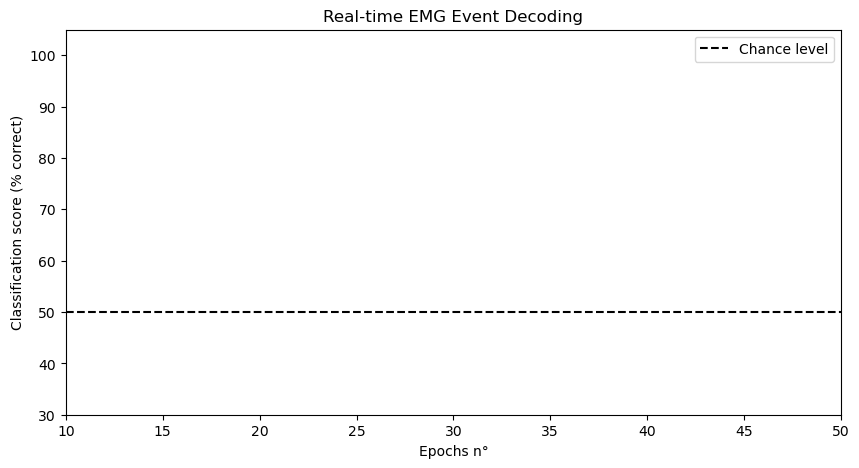

KeyboardInterrupt: 

In [28]:
# Prepare figure for real-time plotting
plt.ion()
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel("Epochs n°")
ax.set_ylabel("Classification score (% correct)")
ax.set_title("Real-time EMG Event Decoding")
ax.set_xlim([10, 50])  # Start showing after 10 epochs
ax.set_ylim([30, 105])
ax.axhline(50, color="k", linestyle="--", label="Chance level")
plt.legend()
plt.show()

# Decoding loop
scores_x, scores, std_scores = [], [], []
min_epochs = 10  # Minimum epochs to start showing results

while True:
    n_epochs = len(epochs)  # Current number of epochs
    
    # Wait until we have enough epochs
    if n_epochs < min_epochs:
        time.sleep(0.5)
        continue
        
    # Only evaluate every 5 new epochs
    if n_epochs % 5 != 0:
        time.sleep(0.1)
        continue
        
    # Break if we've processed 50 epochs
    if len(scores_x) != 0 and scores_x[-1] >= 50:
        break
        
    # Get data and labels
    X = epochs.get_data()  # Shape (n_epochs, 1, n_times)
    y = epochs.events[:, 2]  # Event labels (all 1s in your case)
    
    # Cross-validation
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
    scores_t = cross_val_score(classifier, X, y, cv=cv, n_jobs=1) * 100
    
    # Store results
    std_scores.append(scores_t.std())
    scores.append(scores_t.mean())
    scores_x.append(n_epochs)
    
    # Update plot
    if len(scores_x) > 1:
        ax.plot(scores_x[-2:], scores[-2:], "-x", color="b")
        hyp_limits = (
            np.array(scores[-2:]) - np.array(std_scores[-2:]),
            np.array(scores[-2:]) + np.array(std_scores[-2:]),
        )
        ax.fill_between(
            scores_x[-2:], hyp_limits[0], hyp_limits[1], color="b", alpha=0.5
        )
    plt.pause(0.1)
    plt.draw()

plt.ioff()
plt.show()